# EXPLANATIONS!

In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch
import yaml

from resnet_18 import make_resnet18
from bcos.modules.bcosconv2d import BcosConv2d
from functools import partial
from jsonschema import validate, ValidationError
from logging.handlers import RotatingFileHandler
from IPython.display import Audio
from scipy.io.wavfile import write
import torch.nn.functional as F

from audio_dataset import CatDogAudioDataset, LABEL_MAP, REVERSE_LABEL_MAP
from custom_logger_formatter import CustomLoggerFormatter
from config.config_validation_template import CONFIG_TEMPLATE
from main import DATASET_MAPPING
from tune import TUNABLE_PARAMS

### 0. Config & setup

In [2]:
EXPERIMENT_DIR = r"output\06-06-2026--22-33" # change directory to the specific experiment

BEST_MODEL_DIR = r"job_0" # folder containing .pt model, relative from `EXPERIMENT_DIR`

DEVICE = "cuda" # use if CUDA or ROCm

In [3]:
# Initialise Logger.
def _make_stream_handler(level: int) -> logging.StreamHandler:
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(level)
    ch.setFormatter(CustomLoggerFormatter())
    return ch

level: int=logging.DEBUG
logger = logging.getLogger("test logger")
logger.setLevel(level)
logger.propagate = False  
ch = _make_stream_handler(level)
logger.addHandler(ch)
f_ch = RotatingFileHandler(f"{EXPERIMENT_DIR}/explanations.log")
f_ch.setLevel(level)
f_ch.setFormatter(
    logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )
)
logger.addHandler(f_ch)

logger.info(f"This file logs the testing process.")

2026-06-08 15:04:03,963 - test logger - INFO - This file logs the testing process. (776942466.py:23)


In [4]:
# validate the provided config file.
with open(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/run_config.yml", 'r') as stream:
    CONFIG = yaml.safe_load(stream)

# Get the general config settings from the main yaml
with open(f"{EXPERIMENT_DIR}/config.yml", 'r') as stream:
    general_config = yaml.safe_load(stream)

CONFIG["general"] = general_config["general"]

try:
    validate(general_config, CONFIG_TEMPLATE)
except ValidationError as e:
    raise ValidationError(
        "\x1b[31;1mA validation error occurred in the config file" \
        f": {e.message}\x1b[0m"
    ) from e

for tunable_param in TUNABLE_PARAMS.keys():
    if type(CONFIG[tunable_param]) == list:
        CONFIG[tunable_param] = CONFIG[tunable_param][0]

logger.info("config: {CONFIG}")

2026-06-08 15:04:03,986 - test logger - INFO - config: {CONFIG} (3916436664.py:23)


### 1. Load data


In [5]:
dataset = CatDogAudioDataset(
    data_dirs=DATASET_MAPPING["train"],
    target_sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_fft=CONFIG["n_fft"],
    hop_length=CONFIG["hop_length"],
    n_mels=CONFIG["n_mels"],
    top_db=CONFIG["top_db"],
)
logger.debug(f"Dataset size: {len(dataset)}")
logger.debug(f"Shape of first x element: {dataset[0][0].shape}")
logger.debug(f"First y element: {dataset[0][1]}")
test_data = CatDogAudioDataset(
    data_dirs=DATASET_MAPPING["test"],
    target_sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_fft=CONFIG["n_fft"],
    hop_length=CONFIG["hop_length"],
    n_mels=CONFIG["n_mels"],
    top_db=CONFIG["top_db"],
)
logger.debug(f"Test dataset size: {len(test_data)}")

# Normalise
logger.debug("Fitting normalisation.")
dataset.fit_normalisation(list(range(len(dataset))))
test_data.mean = dataset.mean
test_data.std = dataset.std
logger.debug(
    "Normalisation fitted: "
    f"mean={dataset.mean}, std={dataset.std}"
)

2026-06-08 15:04:04,773 - test logger - DEBUG - Dataset size: 417 (1492243277.py:10)
2026-06-08 15:04:04,808 - test logger - DEBUG - Shape of first x element: torch.Size([1, 128, 128]) (1492243277.py:11)
2026-06-08 15:04:04,811 - test logger - DEBUG - First y element: 0 (1492243277.py:12)
2026-06-08 15:04:05,061 - test logger - DEBUG - Test dataset size: 113 (1492243277.py:22)
2026-06-08 15:04:05,062 - test logger - DEBUG - Fitting normalisation. (1492243277.py:25)
2026-06-08 15:04:06,181 - test logger - DEBUG - Normalisation fitted: mean=-17.01069450378418, std=17.397018432617188 (1492243277.py:29)


In [6]:
# upload your own dataset
# test_data = CatDogAudioDataset(
#     data_dirs="data/personal_recordings/",
#     target_sr=CONFIG["sample_rate"],
#     duration=CONFIG["duration"],
#     n_fft=CONFIG["n_fft"],
#     hop_length=CONFIG["hop_length"],
#     n_mels=CONFIG["n_mels"],
#     top_db=CONFIG["top_db"],
# )
# logger.debug(f"Test dataset size: {len(test_data)}")

# test_data.mean = dataset.mean
# test_data.std = dataset.std

### 2. Load model

In [7]:
models = {
    "resnet18": (
        make_resnet18, {
            "logger": logger,
            "num_classes": dataset.get_n_classes(),
            "in_chans" : 1, 
            "small_inputs": True,
            "conv_layer": partial(BcosConv2d, b=2, max_out=2), 
        }
    ),
}
model = None
for name, (cls, kwargs) in models.items():
    if CONFIG['model'].lower() in name:
        model = cls(**kwargs)
        break
assert model is not None, \
    f"Provided model in config does not exist ({model})."

logger.debug(f"Model:\n{model}")
logger.debug("Total number of parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

model = model.to(DEVICE)


2026-06-08 15:04:06,342 - test logger - DEBUG - Model:
EnhancedResNet(
  (conv1): BcosConv2d(
    B=2, max_out=2,
    (linear): NormedConv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (bn1): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (bn1): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True)
      (conv2): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (bn2): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True)
    )
    (1): BasicBlock(
      (conv1): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), paddi

In [8]:
model_file_path = [entry for entry in os.listdir(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}") if entry.endswith(".pth")][0]

state_dict = torch.load(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/{model_file_path}", weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

### 3. Create the explanations

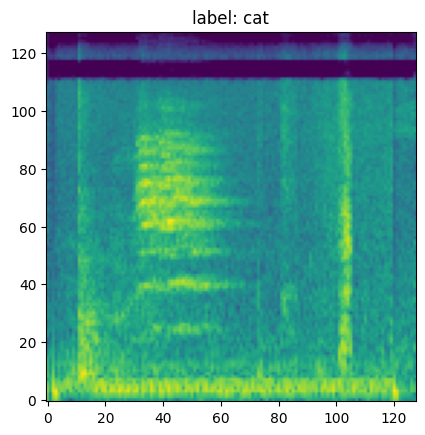

In [9]:
index = 42
SINGLE_TRAIN_IMG = dataset[index][0]
SINGLE_TRAIN_LABEL = dataset[index][1]

plt.imshow(SINGLE_TRAIN_IMG.squeeze(), origin="lower")
plt.title(f"label: {REVERSE_LABEL_MAP[SINGLE_TRAIN_LABEL]}")

display(Audio(dataset.load_waveform(index).squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))
write("test.wav", CONFIG["sample_rate"], dataset.load_waveform(index).squeeze().cpu().numpy())

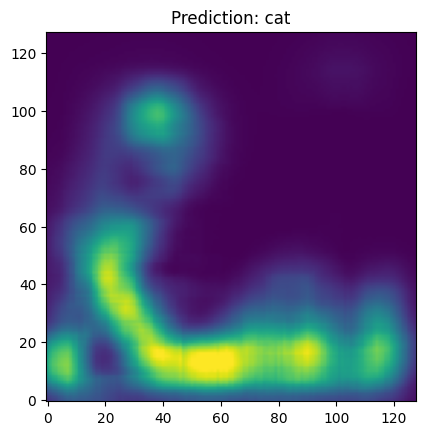

In [10]:
model.eval()
# expl_out = model.explain(SINGLE_TRAIN_IMG.unsqueeze(0).to(DEVICE).requires_grad_(), SINGLE_TRAIN_LABEL)
expl_out = model.explain(SINGLE_TRAIN_IMG.unsqueeze(0).to(DEVICE).requires_grad_())

plt.imshow(expl_out["explanation"], origin="lower")
plt.title(f"Prediction: {REVERSE_LABEL_MAP[expl_out["prediction"]]}")
plt.show()

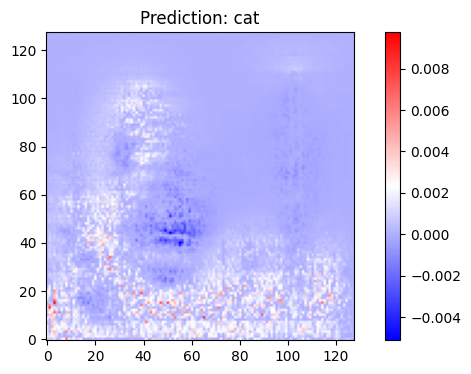

In [11]:
cm = expl_out["contribution_map"][0].cpu().detach().numpy()

plt.figure(figsize=(8,4))
plt.imshow(cm, origin="lower", cmap="bwr")
plt.title(f"Prediction: {REVERSE_LABEL_MAP[expl_out["prediction"]]}")
plt.colorbar()

2026-06-08 15:04:09,691 - test logger - INFO - cm.min() = np.float32(-0.0051207272), cm.max() =np.float32(0.009760103) (2562529254.py:3)
2026-06-08 15:04:09,692 - test logger - INFO - (cm > 0).mean() = np.float64(0.71649169921875) (2562529254.py:4)
2026-06-08 15:04:09,692 - test logger - INFO - (cm < 0).mean() = np.float64(0.28350830078125) (2562529254.py:5)


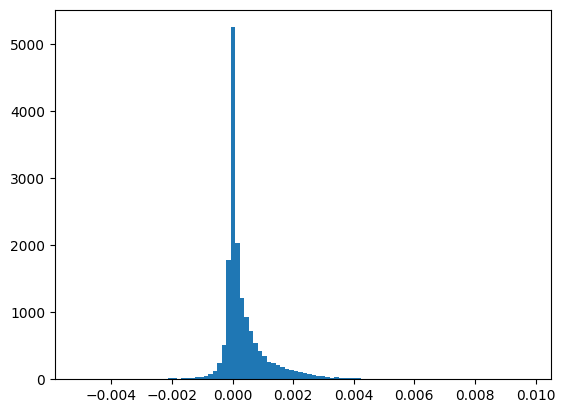

In [12]:
cm = expl_out["contribution_map"][0].cpu().detach().numpy()

logger.info(f"{cm.min() = }, {cm.max() =}")
logger.info(f"{(cm > 0).mean() = }")
logger.info(f"{(cm < 0).mean() = }")

plt.hist(cm.flatten(), bins=100)
plt.show()

2026-06-08 15:04:10,518 - test logger - INFO - Predicting for: dog (2437334267.py:69)
2026-06-08 15:04:10,519 - test logger - INFO - Peak location: (90, 108) (2437334267.py:70)
2026-06-08 15:04:10,519 - test logger - INFO - GridPG hit: False (2437334267.py:71)


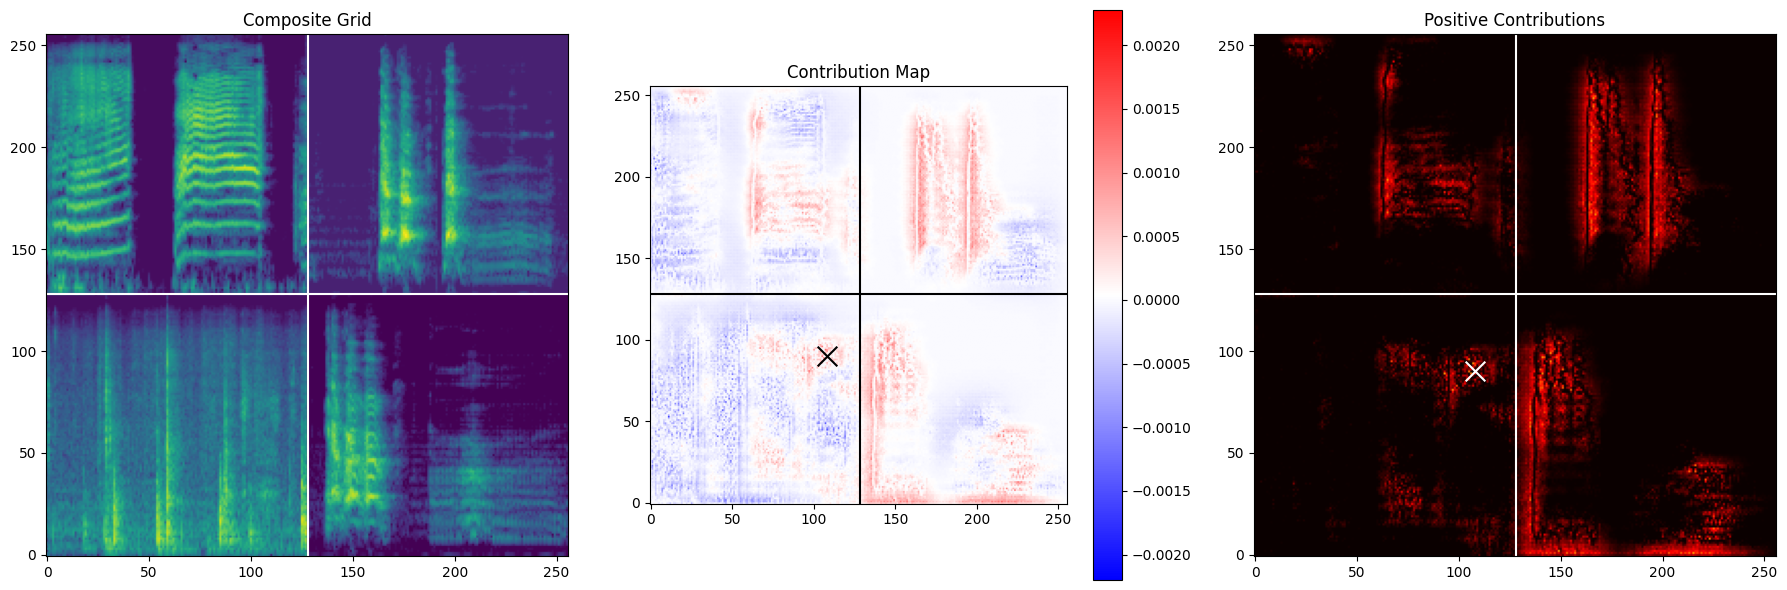

In [13]:
CAT_1, _ = dataset[0]
CAT_2, _ = dataset[3]

DOG_1, _ = dataset[402]
DOG_2, _ = dataset[403]

predict_for_label = "dog"

# --------------------------------------------------
# Build 2x2 grid
#
# CAT | DOG
# ----+----
# CAT | DOG
#
# dog quadrants are top-right and bottom-right
# --------------------------------------------------

def make_grid(a, b, c, d):
    """
    Inputs: tensors (C,H,W)
    Output: tensor (C,2H,2W)
    """

    top = torch.cat([a, b], dim=-1)
    bottom = torch.cat([c, d], dim=-1)

    return torch.cat([top, bottom], dim=-2)

grid_img = make_grid(
    CAT_1,
    DOG_1,
    CAT_2,
    DOG_2,
)

# --------------------------------------------------
# Explain
# --------------------------------------------------

x = (
    grid_img
    .unsqueeze(0)
    .to(DEVICE)
    .requires_grad_()
)

model.eval()

with torch.enable_grad():
    expl_out = model.explain(x, idx=LABEL_MAP[predict_for_label])

cm = expl_out["contribution_map"][0].detach().cpu().numpy()

# --------------------------------------------------
# Grid Pointing Game
# --------------------------------------------------

H, W = cm.shape

peak_y, peak_x = np.unravel_index(
    np.argmax(cm),
    cm.shape
)

# dog quadrants = right half
dog_hit = peak_x >= (W // 2)

logger.info(f"Predicting for: {predict_for_label}")
logger.info(f"Peak location: ({peak_y}, {peak_x})")
logger.info(f"GridPG hit: {dog_hit if predict_for_label == "dog" else not dog_hit}")

# --------------------------------------------------
# Visualisation
# --------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Composite spectrogram
display_img = grid_img.squeeze().cpu().numpy()

ax[0].imshow(display_img, origin="lower")
ax[0].axvline(W//2, color="white")
ax[0].axhline(H//2, color="white")
ax[0].set_title("Composite Grid")

# Contribution map
im = ax[1].imshow(cm, origin="lower", cmap="bwr")
ax[1].scatter(
    peak_x,
    peak_y,
    marker="x",
    s=200,
    c="black"
)
ax[1].axvline(W//2, color="black")
ax[1].axhline(H//2, color="black")
ax[1].set_title("Contribution Map")

plt.colorbar(im, ax=ax[1])

# Positive contributions only
positive_cm = np.maximum(cm, 0)

ax[2].imshow(
    positive_cm,
    origin="lower",
    cmap="hot"
)
ax[2].scatter(
    peak_x,
    peak_y,
    marker="x",
    s=200,
    c="white"
)
ax[2].axvline(W//2, color="white")
ax[2].axhline(H//2, color="white")
ax[2].set_title("Positive Contributions")

plt.tight_layout()
plt.show()

In [14]:
class STFT:
    def __init__(self):
        self.window = torch.hann_window(CONFIG["n_fft"]).to(DEVICE)

    def forward(self, wav):
        return torch.stft(
            wav,
            n_fft=CONFIG["n_fft"],
            hop_length=CONFIG["hop_length"],
            window=self.window,
            return_complex=True
        )

    def inverse(self, spec):
        return torch.istft(
            spec,
            n_fft=CONFIG["n_fft"],
            hop_length=CONFIG["hop_length"],
            window=self.window
        )
    
def mel_to_stft(explanation, stft_spec):
    return F.interpolate(
        input=torch.from_numpy(explanation).squeeze(-1).unsqueeze(0).unsqueeze(0), # (1, 1, n_mels, time)
        size=stft_spec.shape,
        mode="bilinear",
        align_corners=False
    )

In [58]:
def apply_explanation(explanation, wav):
    stft = STFT()
    stft_spec = stft.forward(wav).squeeze(0)

    # mask = mel_to_stft(explanation["explanation"], stft_spec)
    mask = mel_to_stft(explanation, stft_spec).to(DEVICE)
    mask = mask.squeeze(0).squeeze(0)
    
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8) # normalize to [0, 1]
    mask = mask ** 2.5 # sharpen the mask to make important regions more distinct
    # mask = torch.exp(mask) - 1
    # mask = mask / mask.max()

    mag = stft_spec.abs() # strength of each time-frequency bin

    threshold = torch.quantile(mask, 0.9)
    binary_mask = (mask >= threshold).float()
    mag_weighted = mag * binary_mask # only keep the top % most important bins according to the explanation
    #mag_weighted = mag * (mask > mask.mean()).float()
    
    phase = stft_spec.angle() # where in the waveform cycle each bin is (important for reconstructing the audio)
    alpha = 3 # Adjust this to control the strength of the explanation

    mag_masked = mag_weighted * (1.0 + alpha * mask)
    spec_masked = mag_masked * torch.exp(1j * phase)

    #spec_masked = stft_spec * mask
    wav_out = stft.inverse(spec_masked.unsqueeze(0))

    # print(f"Mask stats - Min: {mask.min()}, Max: {mask.max()}, Mean: {mask.mean()}")
    # print(f"Mean absolute difference: {(mag_masked - mag).abs().mean()}")

    return wav_out

In [59]:
CAT_IMG = dataset[42][0]
CAT_LABEL = dataset[42][1]
DOG_IMG = dataset[402][0]
DOG_LABEL = dataset[402][1]

x = torch.cat([CAT_IMG, DOG_IMG], dim=-1)
x = x.unsqueeze(0).to(DEVICE).requires_grad_()
x_wav = torch.cat([
    dataset.load_waveform(42),
    dataset.load_waveform(402)
], dim=-1).to(DEVICE)

model.eval()
with torch.enable_grad():
    expl_out_cat = model.explain(x, idx=LABEL_MAP["cat"])
    expl_out_dog = model.explain(x, idx=LABEL_MAP["dog"])

expl_out_wav_cat = apply_explanation(expl_out_cat["explanation"], x_wav.to(DEVICE))
expl_out_wav_dog = apply_explanation(expl_out_dog["explanation"], x_wav.to(DEVICE))

print("Original CAT + DOG audio:")
display(Audio(x_wav.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))

print("Explanation for CAT prediction:")
display(Audio(expl_out_wav_cat.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))

print("Explanation for DOG prediction:")
display(Audio(expl_out_wav_dog.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))

# --------------------------------------------------
# Storage of the masked audio for sharing
# --------------------------------------------------

write("original_DOG_CAT.wav", CONFIG["sample_rate"], x_wav.squeeze().cpu().numpy())
write("explanation_CAT.wav", CONFIG["sample_rate"], expl_out_wav_cat.squeeze().cpu().numpy())
write("explanation_DOG.wav", CONFIG["sample_rate"], expl_out_wav_dog.squeeze().cpu().numpy())


Original CAT + DOG audio:


Explanation for CAT prediction:


Explanation for DOG prediction:


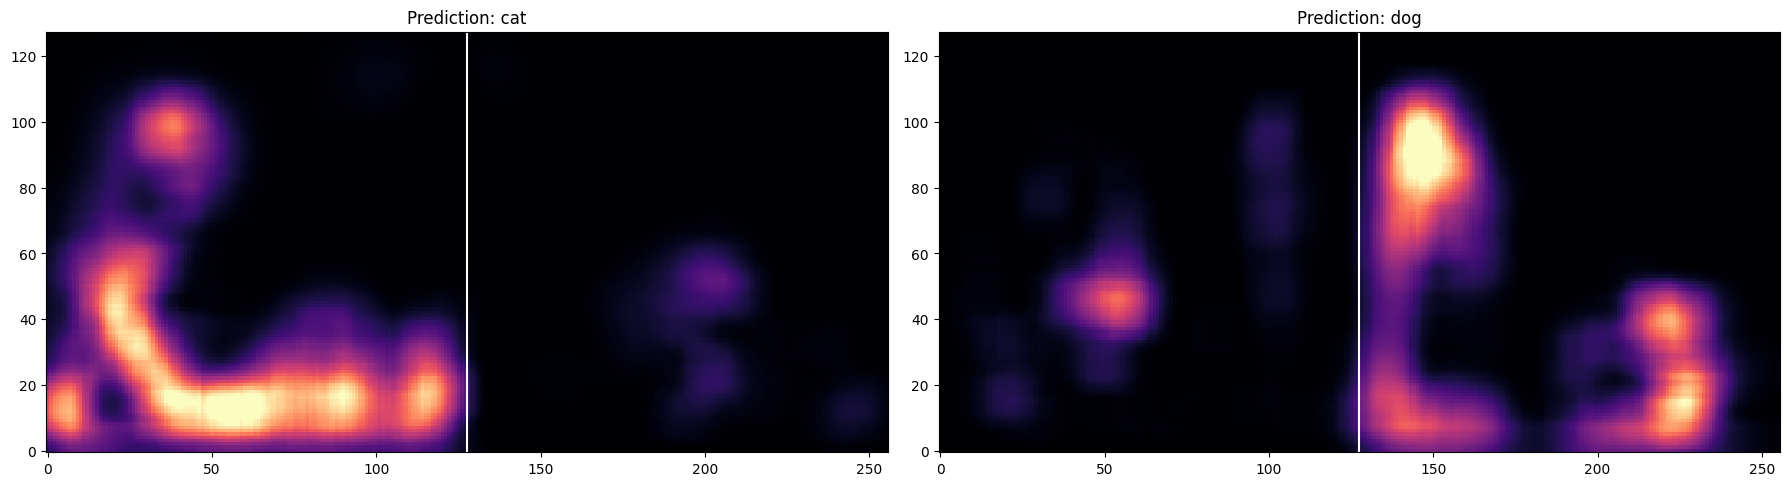

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].imshow(expl_out_cat["explanation"], origin="lower", cmap="magma")
xmin, xmax = ax[0].get_xlim()
center = (xmin + xmax) / 2
ax[0].axvline(center, color="white")
ax[0].set_title(f"Prediction: cat")

ax[1].imshow(expl_out_dog["explanation"], origin="lower", cmap="magma")
ax[1].axvline(center, color="white")
ax[1].set_title(f"Prediction: dog")

plt.tight_layout()
plt.show()


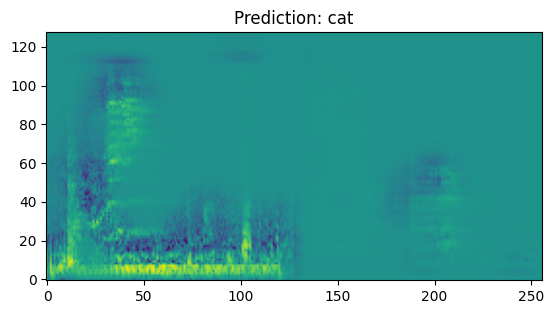

In [66]:
explanation_cat = expl_out_cat["explanation"].squeeze() * x.detach().cpu().numpy().squeeze()
explanation_cat = (explanation_cat - explanation_cat.min()) / (explanation_cat.max() - explanation_cat.min() + 1e-8) # normalize to [0, 1]

plt.imshow(explanation_cat, origin="lower")
plt.title(f"Prediction: cat")
plt.show()
